# Exercise 2

---
## 1. Libraries & Settings

In [1]:
import warnings
import sys
import numpy as np
import pandas as pd
import tabulate as tab
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
%pip install openpyxl
# or to ensure the same Python interp


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
!{sys.executable} -m pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


---
## 2. Load Raw Data


In [4]:
# ============================================================
# 1) Load the already-aligned dataset (monthly, Year-Month aligned)
#    - Sheet "DATA" contains: date, USDJPY, CPI US, CPI JAPAN, FED FUNDS, BOJ RATES
# ============================================================

df = pd.read_excel("aligned_macro_fx_dataset.xlsx")

# ============================================================
# 2) Parse date column and set it as index
#    - Convert to datetime
#    - Set as index (time series format)
# ============================================================
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# ============================================================
# 3) Ensure the dataframe is strictly time-sorted by the index
# ============================================================
df = df.sort_index()

# ============================================================
# 4) Quick data integrity checks (optional but recommended)
#    - Missing values per column
#    - Index frequency sanity check (should look monthly, month-end)
# ============================================================
print("Missing values per column:\n", df.isna().sum(), "\n")
print("Index start/end:", df.index.min(), "->", df.index.max())
print("Number of rows:", len(df), "\n")

# ============================================================
# 5) Build a clean sample with a common window (intersection across all required vars)
#    - This is what you should use for regressions to avoid changing sample sizes silently
# ============================================================
required_cols = ["USDJPY", "CPI US", "CPI JAPAN", "FED FUNDS", "BOJ RATES"]
df_clean = df.dropna(subset=required_cols).copy()

# ============================================================
# 6) (If needed) Compute monthly FX log returns
#    - This is standard for exchange-rate return regressions
#    - fx_ret[t] = log(USDJPY[t]) - log(USDJPY[t-1])
# ============================================================
df_clean["fx_ret"] = np.log(df_clean["USDJPY"]).diff()

# ============================================================
# 7) Final dataset ready for the next step
#    - Sorted by date index
#    - Common window enforced
#    - Optional fx returns computed
# ============================================================
print("\nFinal columns:", df_clean.columns.tolist())
print("Final sample window:", df_clean.index.min(), "->", df_clean.index.max())
df_clean.head(10)

Missing values per column:
 USDJPY       0
CPI US       0
CPI JAPAN    0
FED FUNDS    0
BOJ RATES    0
dtype: int64 

Index start/end: 1990-01-31 00:00:00 -> 2020-01-31 00:00:00
Number of rows: 361 


Final columns: ['USDJPY', 'CPI US', 'CPI JAPAN', 'FED FUNDS', 'BOJ RATES', 'fx_ret']
Final sample window: 1990-01-31 00:00:00 -> 2020-01-31 00:00:00


,USDJPY,CPI US,CPI JAPAN,FED FUNDS,BOJ RATES,fx_ret
date,,,,,,
1990-01-31,144.550448,127.5,89.69203,8.23,6.58059,NaN
1990-02-28,148.809524,128.0,89.79384,8.24,6.64309,0.029039
1990-03-31,157.828283,128.6,90.09926,8.28,6.81696,0.058841
1990-04-30,158.856235,128.9,90.91372,8.26,7.16250,0.006492
1990-05-31,152.648451,129.1,91.32095,8.18,7.25893,-0.039862
1990-06-30,152.346130,129.9,91.01553,8.29,7.36458,-0.001982
1990-07-31,146.134736,130.5,90.81191,8.15,7.52415,-0.041626
1990-08-31,143.926310,131.6,91.11733,8.13,7.54348,-0.015228
1990-09-30,138.274336,132.5,91.82998,8.20,7.76316,-0.040062


In [5]:
# ============================================================
# STEP 1 — Helper: read a FRED-style monthly Excel series
#   Expected structure:
#     - sheet_name="Monthly"
#     - columns: observation_date, <series_col>
#   Output:
#     - Series indexed by datetime (month-end or month-start is fine)
#     - Sorted by index
# ============================================================
def read_monthly_series(file_name: str, series_col: str, out_name: str) -> pd.Series:
    x = pd.read_excel(file_name, sheet_name="Monthly").copy()

    # Standard FRED format
    x = x.rename(columns={"observation_date": "date"})
    if "date" not in x.columns:
        raise KeyError("Expected 'observation_date' column not found in sheet 'Monthly'.")
    if series_col not in x.columns:
        raise KeyError(f"Expected column '{series_col}' not found. Available columns: {list(x.columns)}")

    x["date"] = pd.to_datetime(x["date"])
    x = x.set_index("date").sort_index()

    return x[series_col].astype(float).rename(out_name)

# ============================================================
# STEP 2 — Read the two IP series (from your local working directory)
#   - US:    INDPRO            -> INDUS
#   - Japan: JPNPROINDMISMEI   -> INDJAP
# ============================================================
indus  = read_monthly_series("Industrial Production US.xlsx", "INDPRO", "INDUS")
indjap = read_monthly_series("Production Volume JAPAN.xlsx", "JPNPROINDMISMEI", "INDJAP")

# ============================================================
# STEP 3 — Align by Year-Month before merging
#   Rationale:
#     Even if one file uses month-start and the other month-end timestamps,
#     Year-Month alignment should still match. We enforce this by converting
#     indices to monthly Periods ("YYYY-MM").
# ============================================================
# Create Year-Month keys from df_clean and from both IP series
df_base = df_clean.copy()
df_base["YM"] = df_base.index.to_period("M")

ip_us_df = indus.to_frame()
ip_us_df["YM"] = ip_us_df.index.to_period("M")

ip_jp_df = indjap.to_frame()
ip_jp_df["YM"] = ip_jp_df.index.to_period("M")

# Drop duplicate YM entries if any (keep the last within the month, conservative)
ip_us_df = ip_us_df.sort_index().drop_duplicates(subset=["YM"], keep="last")
ip_jp_df = ip_jp_df.sort_index().drop_duplicates(subset=["YM"], keep="last")

# Keep only the YM + value columns for merge
ip_us_df = ip_us_df[["YM", "INDUS"]]
ip_jp_df = ip_jp_df[["YM", "INDJAP"]]

# ============================================================
# STEP 4 — Merge on YM (Year-Month alignment), then restore date index
#   - Left merge keeps df_clean window as the master sample
#   - After merge, we set index back to the original df_clean date index
# ============================================================
df_clean_full = (
    df_base.reset_index()
          .merge(ip_us_df, on="YM", how="left")
          .merge(ip_jp_df, on="YM", how="left")
          .set_index("date")
          .sort_index()
)

# Drop the auxiliary YM key (no longer needed)
df_clean_full = df_clean_full.drop(columns=["YM"])

# ============================================================
# STEP 5 — Verify Year-Month alignment worked (minimal, deterministic checks)
#   - Confirm that after merge, the YM keys match exactly row-by-row
#   - Report missing values introduced by merge (if any)
# ============================================================
# Year-Month consistency check: index YM should be identical before/after
ym_before = df_clean.index.to_period("M")
ym_after  = df_clean_full.index.to_period("M")
if not ym_before.equals(ym_after):
    raise ValueError("Year-Month alignment failed: df_clean_full index does not match df_clean Year-Month sequence.")

print("Year-Month alignment check: PASSED (df_clean_full matches df_clean by Year-Month).")
print("\nMissing values in the newly merged IP columns (within df_clean window):")
print(df_clean_full[["INDUS", "INDJAP"]].isna().sum())

# df_clean_full is ready for the Taylor rule construction step
df_clean_full.head(10)

Year-Month alignment check: PASSED (df_clean_full matches df_clean by Year-Month).

Missing values in the newly merged IP columns (within df_clean window):
INDUS     0
INDJAP    0
dtype: int64


,USDJPY,CPI US,CPI JAPAN,FED FUNDS,BOJ RATES,fx_ret,INDUS,INDJAP
date,,,,,,,,
1990-01-31,144.550448,127.5,89.69203,8.23,6.58059,NaN,61.7290,100.9016
1990-02-28,148.809524,128.0,89.79384,8.24,6.64309,0.029039,62.2896,101.4087
1990-03-31,157.828283,128.6,90.09926,8.28,6.81696,0.058841,62.5999,103.2340
1990-04-30,158.856235,128.9,90.91372,8.26,7.16250,0.006492,62.4359,103.4369
1990-05-31,152.648451,129.1,91.32095,8.18,7.25893,-0.039862,62.6258,104.1467
1990-06-30,152.346130,129.9,91.01553,8.29,7.36458,-0.001982,62.8382,104.4509
1990-07-31,146.134736,130.5,90.81191,8.15,7.52415,-0.041626,62.7284,105.3636
1990-08-31,143.926310,131.6,91.11733,8.13,7.54348,-0.015228,62.9475,106.2763
1990-09-30,138.274336,132.5,91.82998,8.20,7.76316,-0.040062,62.9523,105.3636


---
## 3. Building Taylor Rule Regressors

In [6]:
# ============================================================
# CHUNK 1 — Build Taylor-rule regressors from df_clean_full
#   - Inflation (YoY log diff) + inflation gaps (target 2%)
#   - Output gap (HP cycle of log INDUS / INDJAP)
#   - FX gaps (HP cycle of log USDJPY and log JPYUSD)
#   - Creates: df_taylor (same index as df_clean_full, sorted)
# ============================================================

from statsmodels.tsa.filters.hp_filter import hpfilter

# ----------------------------
# 0) Start from df_clean_full
# ----------------------------
df_taylor = df_clean_full.copy()
df_taylor = df_taylor.sort_index()

# ----------------------------
# 1) Settings
# ----------------------------
PI_TARGET = 2.0         # inflation target, annual percent
HP_LAMBDA = 129600      # monthly HP filter (recommended default)
# HP_LAMBDA = 14400     # alternative (less smoothing)

# ----------------------------
# 2) Inflation: YoY (12-month log difference) in percent
#    pi_t = 100 * (log(CPI_t) - log(CPI_{t-12}))
# ----------------------------
df_taylor["pi_us"] = 100.0 * (np.log(df_taylor["CPI US"]).diff(12))
df_taylor["pi_jp"] = 100.0 * (np.log(df_taylor["CPI JAPAN"]).diff(12))

df_taylor["pi_gap_us"] = df_taylor["pi_us"] - PI_TARGET
df_taylor["pi_gap_jp"] = df_taylor["pi_jp"] - PI_TARGET

# ----------------------------
# 3) Output gap: HP cycle of log Industrial Production
#    - Trend = potential output proxy
#    - Cycle = output gap proxy
# ----------------------------
# US output gap from INDUS
log_indus = np.log(df_taylor["INDUS"]).dropna()
cyc_us, tr_us = hpfilter(log_indus, lamb=HP_LAMBDA)
df_taylor.loc[cyc_us.index, "y_gap_us"] = cyc_us
df_taylor.loc[tr_us.index,  "y_trend_us"] = tr_us   # optional: potential output proxy

# Japan output gap from INDJAP
log_indjap = np.log(df_taylor["INDJAP"]).dropna()
cyc_jp, tr_jp = hpfilter(log_indjap, lamb=HP_LAMBDA)
df_taylor.loc[cyc_jp.index, "y_gap_jp"] = cyc_jp
df_taylor.loc[tr_jp.index,  "y_trend_jp"] = tr_jp   # optional: potential output proxy

# ----------------------------
# 4) FX gaps (nominal): HP cycle of log FX
#    You asked:
#      - For Japan regression: use USDJPY (JPY per USD)
#      - For US regression: use JPYUSD (USD per JPY)
#    We compute BOTH:
#      fx_gap_usdjpy = cycle(log(USDJPY))
#      fx_gap_jpyusd = cycle(log(JPYUSD))
# ----------------------------
df_taylor["JPYUSD"] = 1.0 / df_taylor["USDJPY"]

log_usdjpy = np.log(df_taylor["USDJPY"]).dropna()
fx_cyc_usdjpy, fx_tr_usdjpy = hpfilter(log_usdjpy, lamb=HP_LAMBDA)
df_taylor.loc[fx_cyc_usdjpy.index, "fx_gap_usdjpy"] = fx_cyc_usdjpy
df_taylor.loc[fx_tr_usdjpy.index,  "fx_trend_usdjpy"] = fx_tr_usdjpy  # optional

log_jpyusd = np.log(df_taylor["JPYUSD"]).dropna()
fx_cyc_jpyusd, fx_tr_jpyusd = hpfilter(log_jpyusd, lamb=HP_LAMBDA)
df_taylor.loc[fx_cyc_jpyusd.index, "fx_gap_jpyusd"] = fx_cyc_jpyusd
df_taylor.loc[fx_tr_jpyusd.index,  "fx_trend_jpyusd"] = fx_tr_jpyusd  # optional

# ----------------------------
# 5) Minimal integrity checks (alignment + missingness)
#    We do NOT drop rows globally; we drop NA only at regression time.
# ----------------------------
print("Index sorted:", df_taylor.index.is_monotonic_increasing)
print("\nNA count (core regressors):")
print(df_taylor[["pi_gap_us","y_gap_us","fx_gap_jpyusd","pi_gap_jp","y_gap_jp","fx_gap_usdjpy"]].isna().sum())

df_taylor.head(5)

Index sorted: True

NA count (core regressors):
pi_gap_us        12
y_gap_us          0
fx_gap_jpyusd     0
pi_gap_jp        12
y_gap_jp          0
fx_gap_usdjpy     0
dtype: int64


,USDJPY,CPI US,CPI JAPAN,FED FUNDS,BOJ RATES,fx_ret,INDUS,INDJAP,pi_us,pi_jp,...,pi_gap_jp,y_gap_us,y_trend_us,y_gap_jp,y_trend_jp,JPYUSD,fx_gap_usdjpy,fx_trend_usdjpy,fx_gap_jpyusd,fx_trend_jpyusd
date,,,,,,,,,,,,,,,,,,,,,
1990-01-31,144.550448,127.5,89.69203,8.23,6.58059,NaN,61.7290,100.9016,NaN,NaN,...,NaN,0.027280,4.095474,-0.041856,4.656002,0.006918,-0.023677,4.997305,0.023677,-4.997305
1990-02-28,148.809524,128.0,89.79384,8.24,6.64309,0.029039,62.2896,101.4087,NaN,NaN,...,NaN,0.034444,4.097350,-0.035676,4.654835,0.006720,0.012450,4.990217,-0.012450,-4.990217
1990-03-31,157.828283,128.6,90.09926,8.28,6.81696,0.058841,62.5999,103.2340,NaN,NaN,...,NaN,0.037536,4.099227,-0.016669,4.653668,0.006336,0.078379,4.983129,-0.078379,-4.983129
1990-04-30,158.856235,128.9,90.91372,8.26,7.16250,0.006492,62.4359,103.4369,NaN,NaN,...,NaN,0.033036,4.101105,-0.013538,4.652499,0.006295,0.091959,4.976041,-0.091959,-4.976041
1990-05-31,152.648451,129.1,91.32095,8.18,7.25893,-0.039862,62.6258,104.1467,NaN,NaN,...,NaN,0.034194,4.102984,-0.005529,4.651330,0.006551,0.059185,4.968952,-0.059185,-4.968952


---
## 4. Constructing the Taylor Rules for Japan and US

In [7]:
# ============================================================
# CHUNK 2 — Estimate Taylor rules + compute fitted values
#   - US: FED FUNDS ~ pi_gap_us + y_gap_us + fx_gap_jpyusd
#   - JP: BOJ RATES ~ pi_gap_jp + y_gap_jp + fx_gap_usdjpy
#   - Store fitted values in df_taylor:
#       TR_US_fitted, TR_JP_fitted
# ============================================================

# ----------------------------
# 1) Build regression samples (drop NA only for required columns)
# ----------------------------
us_vars = ["FED FUNDS", "pi_gap_us", "y_gap_us", "fx_gap_jpyusd"]
jp_vars = ["BOJ RATES", "pi_gap_jp", "y_gap_jp", "fx_gap_usdjpy"]

df_us = df_taylor[us_vars].dropna().copy()
df_jp = df_taylor[jp_vars].dropna().copy()

# Alignment sanity check: still time-sorted
df_us = df_us.sort_index()
df_jp = df_jp.sort_index()

print("US sample window:", df_us.index.min(), "->", df_us.index.max(), " n=", len(df_us))
print("JP sample window:", df_jp.index.min(), "->", df_jp.index.max(), " n=", len(df_jp))

# ----------------------------
# 2) Estimate US Taylor rule (OLS + HAC)
# ----------------------------
Y_us = df_us["FED FUNDS"]
X_us = sm.add_constant(df_us[["pi_gap_us", "y_gap_us", "fx_gap_jpyusd"]])

mod_us = sm.OLS(Y_us, X_us).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

# ----------------------------
# 3) Estimate Japan Taylor rule (OLS + HAC)
# ----------------------------
Y_jp = df_jp["BOJ RATES"]
X_jp = sm.add_constant(df_jp[["pi_gap_jp", "y_gap_jp", "fx_gap_usdjpy"]])

mod_jp = sm.OLS(Y_jp, X_jp).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

# ----------------------------
# 4) Betas (clean names) + fitted values
# ----------------------------
betas_us = mod_us.params.rename({
    "const": "alpha_US",
    "pi_gap_us": "phi_pi_US",
    "y_gap_us": "phi_y_US",
    "fx_gap_jpyusd": "phi_fx_US",
})

betas_jp = mod_jp.params.rename({
    "const": "alpha_JP",
    "pi_gap_jp": "phi_pi_JP",
    "y_gap_jp": "phi_y_JP",
    "fx_gap_usdjpy": "phi_fx_JP",
})

print("\n================ US Taylor Rule (HAC SEs) ================")
print(mod_us.summary())
print("\nUS betas:\n", betas_us)

print("\n================ Japan Taylor Rule (HAC SEs) ================")
print(mod_jp.summary())
print("\nJapan betas:\n", betas_jp)

# Fitted values (implied Taylor rates)
df_taylor.loc[df_us.index, "TR_US_fitted"] = mod_us.fittedvalues
df_taylor.loc[df_jp.index, "TR_JP_fitted"] = mod_jp.fittedvalues

# ----------------------------
# 5) Minimal final check
# ----------------------------
print("\nMissing fitted values:")
print(df_taylor[["TR_US_fitted", "TR_JP_fitted"]].isna().sum())

df_taylor.tail(10)

US sample window: 1991-01-31 00:00:00 -> 2020-01-31 00:00:00  n= 349
JP sample window: 1991-01-31 00:00:00 -> 2020-01-31 00:00:00  n= 349

================ US Taylor Rule (HAC SEs) ================
                            OLS Regression Results                            
Dep. Variable:              FED FUNDS   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     6.915
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           0.000156
Time:                        12:26:52   Log-Likelihood:                -706.07
No. Observations:                 349   AIC:                             1420.
Df Residuals:                     345   BIC:                             1436.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
            

,USDJPY,CPI US,CPI JAPAN,FED FUNDS,BOJ RATES,fx_ret,INDUS,INDJAP,pi_us,pi_jp,...,y_trend_us,y_gap_jp,y_trend_jp,JPYUSD,fx_gap_usdjpy,fx_trend_usdjpy,fx_gap_jpyusd,fx_trend_jpyusd,TR_US_fitted,TR_JP_fitted
date,,,,,,,,,,,,,,,,,,,,,
2019-04-30,111.433029,255.233,101.8071,2.42,-0.067,0.005224,102.2740,102.51910,1.980835,0.904110,...,4.628431,0.001112,4.628937,0.008974,-0.003374,4.716798,0.003374,-4.716798,2.402891,1.237514
2019-05-31,108.283703,255.296,101.8071,2.39,-0.049,-0.028669,102.3920,103.61270,1.779975,0.702511,...,4.628882,0.011600,4.629060,0.009235,-0.031832,4.716587,0.031832,-4.716587,2.108343,1.076340
2019-06-30,107.886503,255.213,101.6035,2.38,-0.062,-0.003675,102.4375,102.33690,1.657384,0.603074,...,4.629330,-0.000904,4.629174,0.009269,-0.035288,4.716368,0.035288,-4.716368,1.980613,1.044852
2019-07-31,108.778418,255.802,101.6035,2.40,-0.071,0.008233,101.9408,102.24580,1.809854,0.603074,...,4.629777,-0.001902,4.629282,0.009193,-0.026830,4.716143,0.026830,-4.716143,2.091182,1.027667
2019-08-31,106.258634,256.036,101.8071,2.13,-0.045,-0.023437,102.6390,101.24330,1.722717,0.200186,...,4.630221,-0.011857,4.629383,0.009411,-0.050037,4.715913,0.050037,-4.715913,1.993478,0.751159
2019-09-30,108.073057,256.430,101.9089,2.04,-0.059,0.016931,102.2917,102.42800,1.670467,0.199986,...,4.630665,-0.000320,4.629481,0.009253,-0.032873,4.715680,0.032873,-4.715680,1.968691,0.658721
2019-10-31,108.026358,257.155,102.2143,1.83,-0.021,-0.000432,101.4281,98.78288,1.719112,0.199388,...,4.631107,-0.036650,4.629575,0.009257,-0.033070,4.715445,0.033070,-4.715445,1.902977,0.812369
2019-11-30,109.493047,257.879,102.3161,1.55,-0.043,0.013486,101.9372,98.05386,2.070703,0.498719,...,4.631549,-0.044150,4.629667,0.009133,-0.019349,4.715210,0.019349,-4.715210,2.341116,1.089737
2019-12-31,108.636611,258.630,102.3161,1.55,-0.038,-0.007853,101.7003,98.41837,2.293035,0.799149,...,4.631990,-0.040531,4.629758,0.009205,-0.026965,4.714973,0.026965,-4.714973,2.481321,1.375096


### Line Chart of Implied Taylor Rates vs Observed Rates

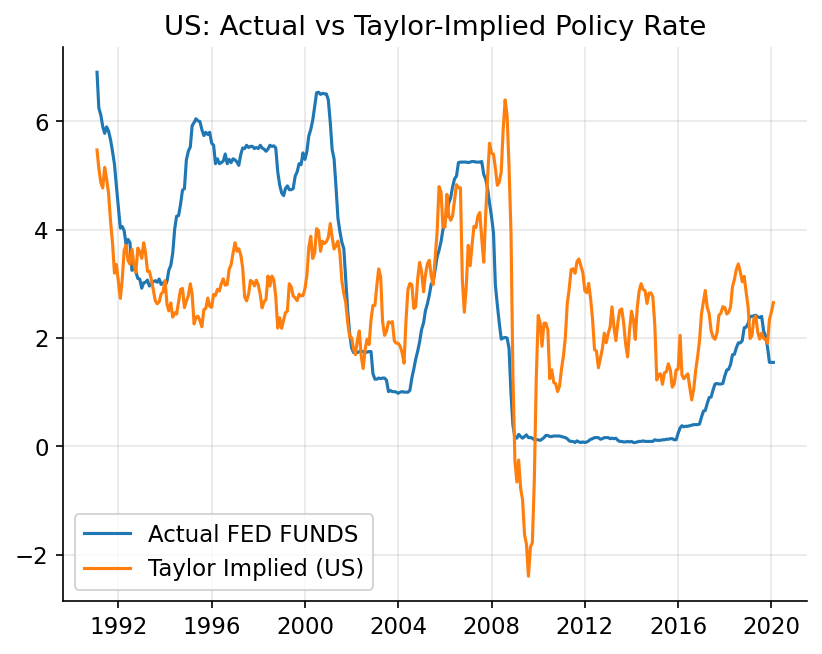

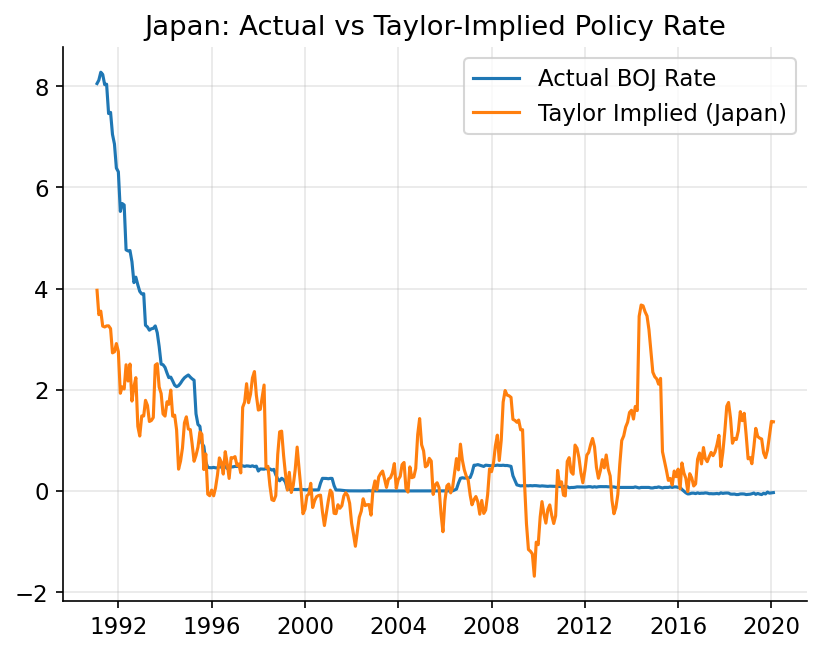

In [8]:
# ----------------------------
# 1) US comparison
# ----------------------------
df_plot_us = df_taylor[["FED FUNDS", "TR_US_fitted"]].dropna()

plt.figure()
plt.plot(df_plot_us.index, df_plot_us["FED FUNDS"], label="Actual FED FUNDS")
plt.plot(df_plot_us.index, df_plot_us["TR_US_fitted"], label="Taylor Implied (US)")
plt.title("US: Actual vs Taylor-Implied Policy Rate")
plt.legend()
plt.show()

# ----------------------------
# 2) Japan comparison
# ----------------------------
df_plot_jp = df_taylor[["BOJ RATES", "TR_JP_fitted"]].dropna()

plt.figure()
plt.plot(df_plot_jp.index, df_plot_jp["BOJ RATES"], label="Actual BOJ Rate")
plt.plot(df_plot_jp.index, df_plot_jp["TR_JP_fitted"], label="Taylor Implied (Japan)")
plt.title("Japan: Actual vs Taylor-Implied Policy Rate")
plt.legend()
plt.show()

---
## 5. Predict One Month Ahead FX Return

### Compute the Model-implied policy stance differential 

In [12]:
# ============================================================
# Compute implied Taylor-rate differential
#   Δi_hat_t = TR_US_fitted - TR_JP_fitted
# ============================================================

# 1) Keep only periods where both fitted values exist
df_diff = df_taylor[["TR_US_fitted", "TR_JP_fitted"]].dropna().copy()

# 2) Compute differential
df_diff["TR_differential"] = (
    df_diff["TR_US_fitted"] - df_diff["TR_JP_fitted"]
)

# 3) Merge back into main dataframe (aligned by date)
df_taylor.loc[df_diff.index, "TR_differential"] = df_diff["TR_differential"]

# 4) Sanity check
print("Sample window for differential:")
print(df_diff.index.min(), "->", df_diff.index.max())
print("\nPreview:")
df_taylor[["TR_US_fitted", "TR_JP_fitted", "TR_differential"]].dropna().head()

Sample window for differential:
1991-01-31 00:00:00 -> 2020-01-31 00:00:00

Preview:


,TR_US_fitted,TR_JP_fitted,TR_differential
date,,,
1991-01-31,5.473542,3.966751,1.506791
1991-02-28,5.139647,3.486008,1.653639
1991-03-31,4.871229,3.554722,1.316507
1991-04-30,4.772044,3.258899,1.513145
1991-05-31,5.151067,3.241907,1.909160



### FX Predictive Regression


In [13]:
# ----------------------------
# 1) Build regression dataset
# ----------------------------

df_reg = df_taylor[["fx_ret", "TR_differential"]].copy()

# Lead the return (t+1)
df_reg["fx_ret_lead"] = df_reg["fx_ret"].shift(-1)

# Drop NA values
df_reg = df_reg.dropna()

# ----------------------------
# 2) OLS regression
# ----------------------------

Y = df_reg["fx_ret_lead"]
X = sm.add_constant(df_reg["TR_differential"])

model_fx = sm.OLS(Y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})

print("\n================ FX Predictive Regression =================")
print(model_fx.summary())

beta_hat = model_fx.params["TR_differential"]
print("\nEstimated Beta:", beta_hat)

# ----------------------------
# 3) Predicted FX returns
# ----------------------------

df_reg["fx_ret_predicted"] = model_fx.fittedvalues

# Merge back into df_taylor
df_taylor.loc[df_reg.index, "fx_ret_predicted"] = df_reg["fx_ret_predicted"]

df_taylor[["fx_ret", "fx_ret_predicted"]].dropna().head()


================ FX Predictive Regression =================
                            OLS Regression Results                            
Dep. Variable:            fx_ret_lead   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.305
Date:                Sat, 21 Feb 2026   Prob (F-statistic):              0.254
Time:                        12:40:26   Log-Likelihood:                 726.47
No. Observations:                 348   AIC:                            -1449.
Df Residuals:                     346   BIC:                            -1441.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

,fx_ret,fx_ret_predicted
date,,
1991-01-31,-0.032194,0.000085
1991-02-28,0.011237,-0.000111
1991-03-31,0.056049,0.000339
1991-04-30,-0.030465,0.000077
1991-05-31,0.014978,-0.000451


The regression results indicate that the Taylor-rule-implied interest rate differential does not significantly predict next-period USD/JPY returns. The estimated slope coefficient is negative and statistically insignificant, and the explanatory power (R² ≈ 0.004) is effectively zero. Econometrically, this means that variations in the implied policy differential contain almost no information about monthly exchange rate movements.From a macroeconomic perspective, this outcome is fully consistent with the well-documented failure of Uncovered Interest Parity (UIP). UIP predicts that currencies with higher interest rates should depreciate in expectation, such that the interest differential equals expected exchange rate changes. However, empirically this relationship is weak, unstable, and often exhibits the wrong sign — a phenomenon known as the forward premium puzzle. There are several structural reasons for this failure. First, exchange rates embed time-varying risk premia. Investors demand compensation for bearing currency risk, and this premium fluctuates with global risk appetite and financial conditions. Second, monetary policy is endogenous: central banks adjust interest rates in response to macroeconomic shocks, meaning rates reflect economic conditions rather than exogenous drivers of currency movements. Third, capital flows dominate slow-moving macro gaps. Portfolio reallocations, carry trades, and global liquidity conditions often outweigh inflation or output considerations in the short run. Finally, expectations are nonlinear and regime-dependent. Exchange rates react to anticipated regime shifts (e.g., tightening cycles, policy reversals, crises) rather than to current observed differentials. As a result, a linear monthly regression is unlikely to capture these dynamics.

The disconnect is amplified in the case of Japan. The Bank of Japan does not operate under a standard Taylor-rule framework in the same way as a textbook inflation-targeting central bank. For decades, Japanese monetary policy has been shaped by structural deflationary pressures, financial stability concerns, public debt sustainability, and more recently Yield Curve Control. The exchange rate is not a primary optimization variable; instead, policy decisions are influenced by broader macro-financial stability objectives. As a consequence, the Taylor-implied policy rate for Japan may differ substantially from the actual policy stance adopted by the BOJ. The implied rule assumes systematic responses to inflation and output gaps, whereas actual policy may reflect institutional constraints, political considerations, or unconventional policy tools. Therefore, the implied interest differential may not represent a meaningful or tradable monetary stance. If the regressor does not capture the true policy reaction function, its predictive content for exchange rates is naturally weakened. Including the FX gap directly inside the Japan Taylor rule introduces an additional complication. If the exchange rate (or its misalignment) enters the policy rule, and the policy rule then feeds into the interest differential used to predict future exchange rate changes, a feedback loop is created. In this case, the explanatory variable partially embeds information about the dependent variable. This weakens identification and reduces interpretability. Instead of testing whether monetary differentials forecast exchange rate movements, the model risks reintroducing exchange rate dynamics into the regressor itself. Moreover, if the BOJ’s reaction to the exchange rate is episodic and nonlinear rather than systematic and linear, including the FX gap may simply add noise. As a result, predictability may deteriorate rather than improve.

In summary, the empirical failure of the Taylor-rule differential to predict monthly USD/JPY returns is economically coherent. Exchange rates are driven by risk premia, capital flows, and regime-dependent expectations rather than by slow-moving macro gaps. The structural features of Japanese monetary policy further weaken the theoretical link implied by UIP, and incorporating the FX gap into the policy rule may introduce feedback effects that reduce forecasting power rather than enhance it


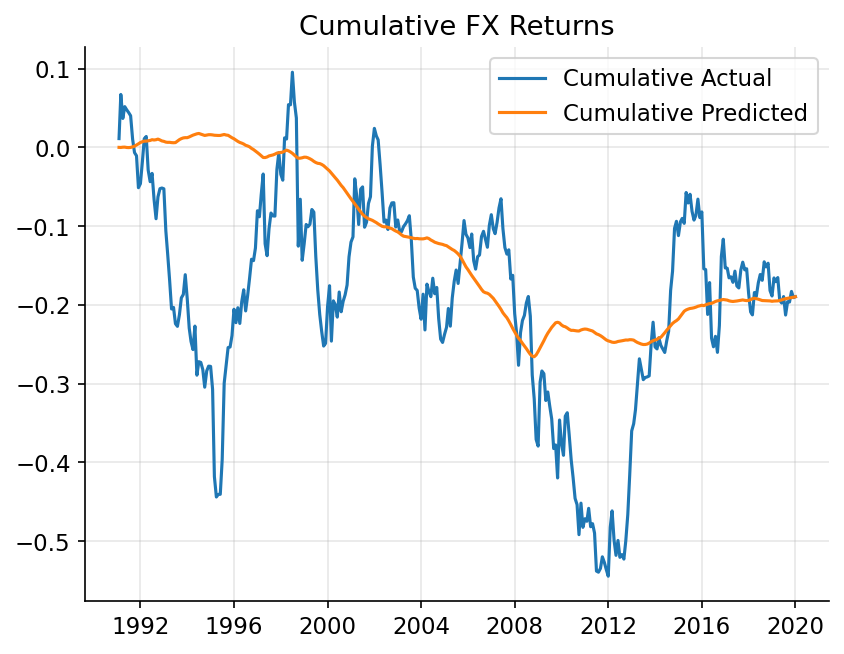

In [16]:
df_reg["cum_actual"] = df_reg["fx_ret_lead"].cumsum()
df_reg["cum_predicted"] = df_reg["fx_ret_predicted"].cumsum()

plt.figure()
plt.plot(df_reg.index, df_reg["cum_actual"], label="Cumulative Actual")
plt.plot(df_reg.index, df_reg["cum_predicted"], label="Cumulative Predicted")
plt.legend()
plt.title("Cumulative FX Returns")
plt.show()

The cumulative comparison clearly illustrates the structural limitation of the implied Taylor-rule differential as a predictor of exchange rate dynamics. The blue line (cumulative actual FX returns) exhibits pronounced cyclical swings, sharp drawdowns, and strong recovery phases. These movements reflect capital inflows and outflows driven by global risk appetite, carry trade unwinds, monetary regime shifts, and macro-financial shocks. The exchange rate adjusts rapidly when positioning changes or when expectations about future policy paths shift abruptly. By contrast, the orange line (cumulative predicted returns based on the Taylor-rule differential) evolves smoothly and gradually. It does not react to abrupt inflow/outflow episodes, nor does it capture the high-frequency volatility embedded in currency markets. The implied Taylor differential is fundamentally a slow-moving macro signal derived from inflation and output gaps. As such, it reflects structural policy stance rather than the short-term capital flow dynamics that dominate FX markets.

This mismatch explains the weak predictive performance. The model captures a very low-frequency drift component, while the exchange rate is largely driven by faster-moving risk premia and regime-dependent expectations. When global investors reprice risk or unwind carry positions, exchange rates adjust immediately. A Taylor-implied differential, however, adjusts only gradually because inflation gaps, output gaps, and HP-filtered trends move slowly by construction. In other words, the implied Taylor rule is too inertial relative to the speed of FX capital flows. It fails not because it is incorrectly specified econometrically, but because it operates at a different frequency than the underlying drivers of currency returns. The cumulative chart makes this visually evident: the predicted path lacks the amplitude and responsiveness necessary to track the inflow and outflow dynamics that characterize USD/JPY movements. This reinforces the broader macro conclusion: exchange rates are not primarily driven by slow-moving policy reaction functions at the monthly horizon, but by time-varying risk premia, liquidity conditions, and regime shifts.
